# Анализ обращений пользователей в поддержку

**Проект:** Support Insights — сервис хранения, категоризации и анализа обращений.
Этот ноутбук — исследовательская часть: здесь я разбираю накопленные данные, проверяю гипотезы
и обосновываю решения, которые потом ушли в веб-приложение (автокатегоризация, детектор всплесков,
рейтинг проблем, сравнение периодов).

**Данные:** 13 тысяч обращений в поддержку крупного цифрового сервиса (соцсеть с мессенджером,
музыкой, видео и платными подписками) с 1 января по 29 сентября 2026 года. Файл `data/tickets.csv`
выгружается скриптом `python -m scripts.seed`.

**Вопросы, на которые ищу ответ:**
1. Растёт ли поток обращений и как он распределён во времени?
2. На что жалуются чаще всего и что меняется от месяца к месяцу?
3. Где поддержка работает медленно и где пользователи недовольны?
4. Можно ли доверить первичную разметку обращений правилам на ключевых словах?
5. Можно ли автоматически ловить инциденты по резкому росту обращений?

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from app import analytics as an                      # те же функции, что в веб-приложении
from app.categorizer import KeywordCategorizer, DEFAULT_CATEGORIES

pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.figsize": (12, 4.5), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 11})
COLORS = {v["name"]: v["color"] for v in DEFAULT_CATEGORIES.values()}

## 1. Загрузка и первичный осмотр

In [2]:
df = pd.read_csv(ROOT / "data" / "tickets.csv", parse_dates=["created_at", "resolved_at"])
df["tags"] = df["tags"].fillna("").map(lambda s: [t for t in s.split("|") if t])
df["category_source"] = np.where(df["category"] == df["auto_category"], "auto", "manual")
df["resolution_h"] = (df["resolved_at"] - df["created_at"]).dt.total_seconds() / 3600
df["date"] = df["created_at"].dt.normalize()
print(f"Обращений: {len(df):,}".replace(",", " "))
print(f"Период: {df['created_at'].min():%d.%m.%Y} — {df['created_at'].max():%d.%m.%Y}")
df.head(3)

Обращений: 13 010
Период: 01.01.2026 — 29.09.2026


,id,created_at,resolved_at,user_ref,channel,platform,subject,text,category,auto_category,confidence,status,priority,csat,tags,category_name,category_source,resolution_h,date
0,1,2026-01-01 03:14:43,2026-01-11 07:30:54,id290385259,app,android,Кнопка не нажимается,Кнопка «Сохранить» в настройках профиля не нажимается.,bugs,bugs,1.0,resolved,normal,NaN,[],Технические ошибки,auto,244.269722,2026-01-01
1,2,2026-01-01 05:21:49,2026-01-01 20:36:45,id161045822,web,web,Подписка не активна,"Оплатил VK Combo, чек пришёл, а подписка в профиле не активна.",payments,payments,1.0,resolved,normal,5.0,[],Платежи и подписки,auto,15.248889,2026-01-01
2,3,2026-01-01 06:42:58,2026-01-01 09:41:49,id433074125,app,ios,Ошибка,"Здравствуйте. Третий раз обращаюсь. Выдаёт ошибку «Не удалось воспроизвести», другие ф...",media,bugs,1.0,resolved,normal,4.0,"[ios, повторное]",Музыка и видео,manual,2.980833,2026-01-01


In [3]:
# Типы и пропуски. Пропуски в resolved_at — открытые обращения, в csat — пользователь не поставил оценку.
pd.DataFrame({"тип": df.dtypes.astype(str), "пропусков": df.isna().sum(),
              "доля пропусков, %": (df.isna().mean() * 100).round(1)})

,тип,пропусков,"доля пропусков, %"
id,int64,0,0.0
created_at,datetime64[us],0,0.0
resolved_at,datetime64[us],84,0.6
user_ref,str,0,0.0
channel,str,0,0.0
platform,str,0,0.0
subject,str,0,0.0
text,str,0,0.0
category,str,0,0.0
auto_category,str,0,0.0


In [4]:
# Проверки качества: дубликаты, логика дат, допустимые значения
checks = {
    "дубликаты id": df["id"].duplicated().sum(),
    "решено раньше, чем создано": (df["resolved_at"] < df["created_at"]).sum(),
    "закрыто без даты решения": (df["status"].isin(["resolved", "closed"]) & df["resolved_at"].isna()).sum(),
    "CSAT вне 1–5": (~df["csat"].dropna().between(1, 5)).sum(),
    "пустой текст": (df["text"].str.strip() == "").sum(),
}
pd.Series(checks, name="нарушений")

дубликаты id                  0
решено раньше, чем создано    0
закрыто без даты решения      0
CSAT вне 1–5                  0
пустой текст                  0
Name: нарушений, dtype: int64

Данные чистые: дублей нет, даты согласованы, оценки в допустимом диапазоне. Можно анализировать.

## 2. Динамика обращений

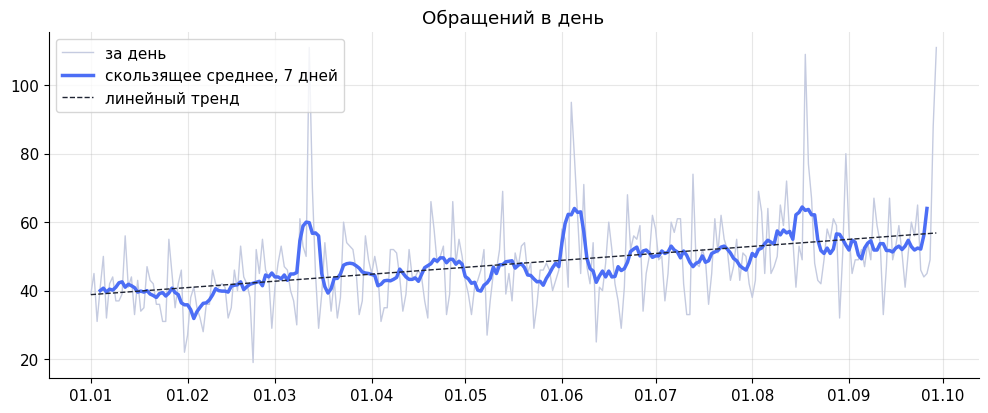

Тренд: +2.0 обращения в день за каждый месяц (с 39 в начале года до 57 к концу сентября, +46%).


In [5]:
daily = df.groupby("date").size()
roll = daily.rolling(7, center=True).mean()

fig, ax = plt.subplots()
ax.plot(daily.index, daily.values, color="#c5cbe0", lw=1, label="за день")
ax.plot(roll.index, roll.values, color="#4C6EF5", lw=2.5, label="скользящее среднее, 7 дней")
x = (daily.index - daily.index[0]).days.values
k, b = np.polyfit(x, daily.values, 1)
ax.plot(daily.index, k * x + b, "--", color="#1f2433", lw=1, label="линейный тренд")
ax.set_title("Обращений в день")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.legend()
plt.show()

print(f"Тренд: +{k * 30:.1f} обращения в день за каждый месяц "
      f"(с {b:.0f} в начале года до {k * x[-1] + b:.0f} к концу сентября, +{k * x[-1] / b * 100:.0f}%).")

In [6]:
top_days = daily.sort_values(ascending=False).head(6)
top_days.index = top_days.index.strftime("%d.%m.%Y")
top_days.to_frame("обращений").T

date,29.09.2026,12.03.2026,18.08.2026,04.06.2026,28.09.2026,31.08.2026
обращений,111,111,109,95,88,80


Поток растёт линейно — это рост аудитории. На его фоне видны резкие пики: 12 марта, 4 июня, 18 августа
и 28–29 сентября. Это не шум: в обычный день приходит 40–60 обращений, в пиковые — вдвое больше.
Ниже разберу, откуда они взялись.

## 3. Когда пишут: неделя и сутки

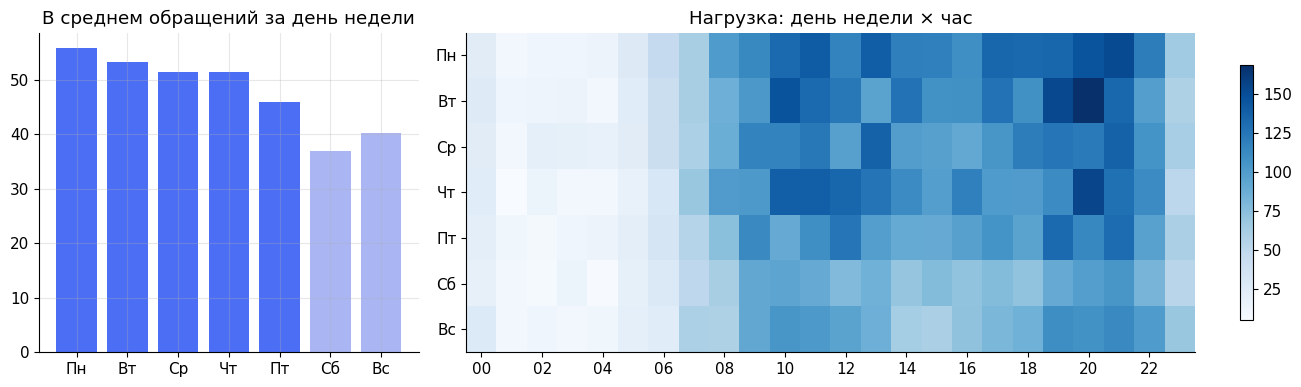

Понедельник загруженнее субботы на 51%.
С 10 до 14 и с 19 до 23 приходит 50% обращений, с 0 до 7 — 7%.


In [7]:
hm = an.heatmap(df.assign(category_name=df["category_name"]))
fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1, 2.4]})
wd = df.groupby(df["created_at"].dt.weekday).size() / df["date"].groupby(df["created_at"].dt.weekday).nunique()
axes[0].bar(an.WEEKDAYS, wd.values, color=["#4C6EF5"] * 5 + ["#aab6f3"] * 2)
axes[0].set_title("В среднем обращений за день недели")
im = axes[1].imshow(hm.values, aspect="auto", cmap="Blues")
axes[1].set_yticks(range(7), hm.index); axes[1].set_xticks(range(0, 24, 2), [f"{h:02d}" for h in range(0, 24, 2)])
axes[1].set_title("Нагрузка: день недели × час"); axes[1].grid(False)
plt.colorbar(im, ax=axes[1], shrink=0.8)
plt.tight_layout(); plt.show()

hours = df["created_at"].dt.hour.value_counts(normalize=True).sort_index()
print(f"Понедельник загруженнее субботы на {(wd[0] / wd[5] - 1) * 100:.0f}%.")
print(f"С 10 до 14 и с 19 до 23 приходит {hours.loc[[10,11,12,13,19,20,21,22]].sum() * 100:.0f}% обращений, "
      f"с 0 до 7 — {hours.loc[0:6].sum() * 100:.0f}%.")

Выводы для планирования смен: пик в понедельник, провал в выходные; внутри дня два горба — обед и вечер.
Ночью достаточно дежурной смены, а вечером после 19:00 операторов должно быть не меньше, чем днём:
именно вечером люди сидят в соцсети и натыкаются на проблемы.

## 4. На что жалуются

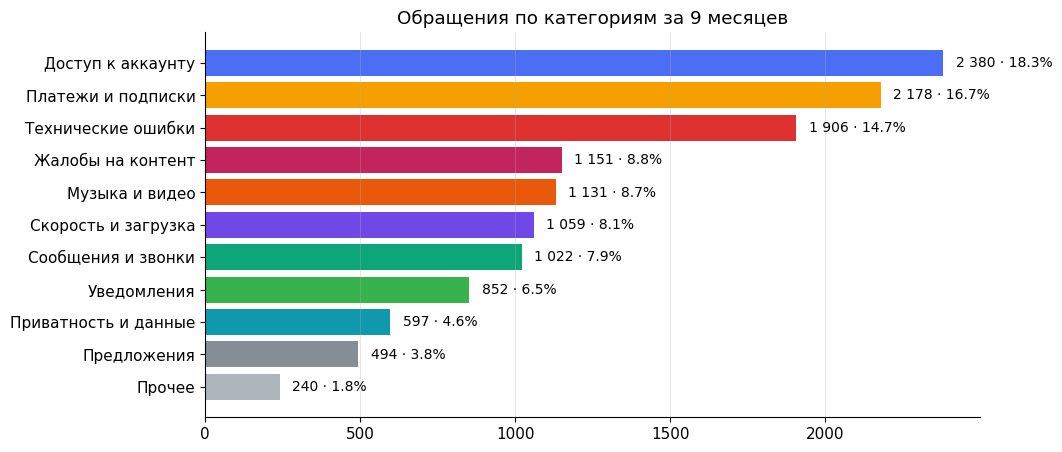

,category_name,count,share,median_resolution_h,avg_csat
0,Доступ к аккаунту,2380,18.3,5.2,4.34
1,Платежи и подписки,2178,16.7,18.7,4.05
2,Технические ошибки,1906,14.7,27.4,3.96
3,Жалобы на контент,1151,8.8,15.4,4.12
4,Музыка и видео,1131,8.7,15.0,4.13
5,Скорость и загрузка,1059,8.1,10.7,4.23
6,Сообщения и звонки,1022,7.9,9.2,4.23
7,Уведомления,852,6.5,13.3,4.15
8,Приватность и данные,597,4.6,35.8,3.78
9,Предложения,494,3.8,66.1,3.44


In [8]:
cs = an.category_stats(df)
fig, ax = plt.subplots(figsize=(10, 5))
d = cs.sort_values("count")
ax.barh(d["category_name"], d["count"], color=[COLORS[n] for n in d["category_name"]])
for i, (c, s) in enumerate(zip(d["count"], d["share"])):
    ax.text(c + 40, i, f"{c:,} · {s}%".replace(",", " "), va="center", fontsize=10)
ax.set_title("Обращения по категориям за 9 месяцев"); ax.grid(axis="y", visible=False)
plt.show()
cs[["category_name", "count", "share", "median_resolution_h", "avg_csat"]]

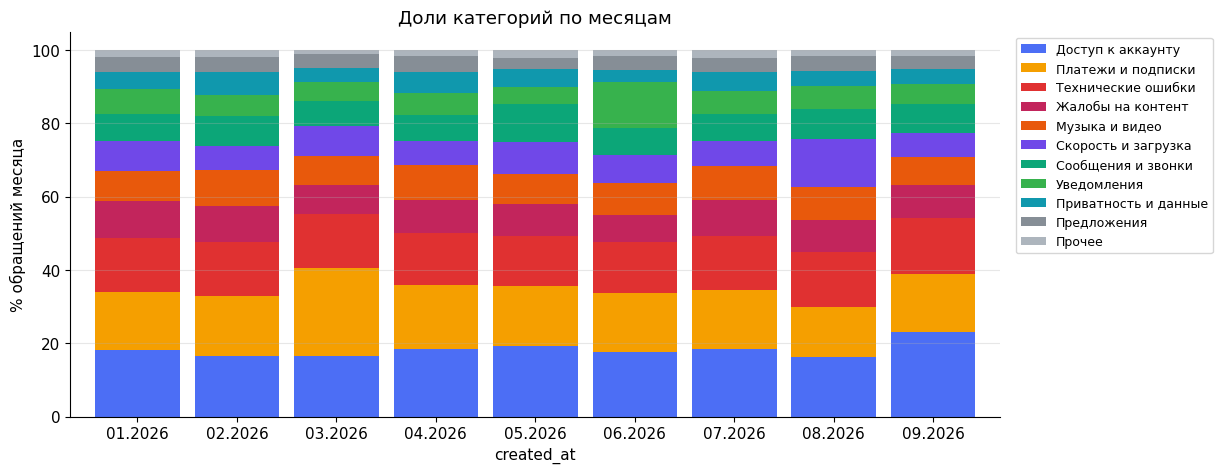

created_at,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06,2026-07,2026-08,2026-09
category_name,,,,,,,,,
Доступ к аккаунту,18.2,16.6,16.5,18.4,19.1,17.7,18.5,16.3,23.0
Платежи и подписки,15.6,16.2,23.9,17.3,16.6,16.1,16.1,13.4,15.8
Технические ошибки,14.9,14.8,14.9,14.2,13.6,13.7,14.8,15.2,15.5
Жалобы на контент,9.9,9.9,7.7,9.1,8.7,7.5,9.7,8.6,9.0
Музыка и видео,8.3,9.8,8.1,9.4,8.2,8.6,9.4,9.1,7.6
Скорость и загрузка,8.1,6.5,8.1,6.5,8.7,7.8,6.8,13.2,6.4
Сообщения и звонки,7.3,8.3,6.7,7.3,10.3,7.4,7.4,8.1,8.0
Уведомления,6.8,5.5,5.3,5.7,4.8,12.5,6.1,6.2,5.5
Приватность и данные,4.7,6.4,3.7,5.7,4.8,3.3,5.2,4.1,4.1


In [9]:
# Структура по месяцам: доли категорий
month = df["created_at"].dt.to_period("M")
share = pd.crosstab(month, df["category_name"], normalize="index") * 100
order = cs["category_name"].tolist()
ax = share[order].plot(kind="bar", stacked=True, figsize=(12, 5), width=0.85,
                       color=[COLORS[c] for c in order])
ax.set_xticklabels([p.strftime("%m.%Y") for p in share.index], rotation=0)
ax.set_ylabel("% обращений месяца"); ax.set_title("Доли категорий по месяцам")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9); ax.grid(axis="x", visible=False)
plt.show()
share[order].round(1).T.style.background_gradient(cmap="Blues", axis=1).format("{:.1f}")

Тройка лидеров стабильна весь год: **доступ к аккаунту, платежи, технические ошибки** — вместе около
половины обращений. Структура от месяца к месяцу почти не плавает, кроме месяцев с инцидентами:
в марте раздуваются «Платежи», в июне — «Уведомления», в августе — «Скорость и загрузка», в сентябре
— «Доступ к аккаунту».

## 5. Каналы и платформы

In [10]:
ct = pd.crosstab(df["category_name"], df["platform"], normalize="columns").mul(100).round(1)
ct = ct.loc[order]
ct.columns = [c.capitalize() for c in ct.columns]
display(pd.crosstab(df["channel"], df["platform"], margins=True, margins_name="всего"))
ct.style.background_gradient(cmap="Blues", axis=None).format("{:.1f}")

platform,android,desktop,ios,web,всего
channel,,,,,
app,4135,0,3010,0,7145
chat_bot,883,0,589,514,1986
email,544,0,390,308,1242
web,0,403,28,2206,2637
всего,5562,403,4017,3028,13010


,Android,Desktop,Ios,Web
category_name,,,,
Доступ к аккаунту,18.4,18.4,17.8,18.8
Платежи и подписки,16.8,14.6,16.9,16.8
Технические ошибки,15.2,14.6,14.3,14.2
Жалобы на контент,9.6,8.2,8.4,8.1
Музыка и видео,8.2,9.9,8.9,9.1
Скорость и загрузка,8.6,6.9,7.5,8.2
Сообщения и звонки,7.5,11.2,7.8,8.2
Уведомления,5.6,5.5,8.6,5.7
Приватность и данные,4.8,4.7,4.6,4.3


In [11]:
# iOS и уведомления: проверяем, не платформенная ли это проблема
june = df[(df["date"] >= "2026-06-04") & (df["date"] <= "2026-06-07") & (df["category"] == "notifications")]
rest = df[(df["category"] == "notifications") & ~df.index.isin(june.index)]
print("Доля iOS среди обращений про уведомления 4–7 июня:", f"{(june['platform'] == 'ios').mean():.0%}")
print("Доля iOS среди обращений про уведомления в остальное время:", f"{(rest['platform'] == 'ios').mean():.0%}")

Доля iOS среди обращений про уведомления 4–7 июня: 94%
Доля iOS среди обращений про уведомления в остальное время: 31%


Июньский всплеск по уведомлениям почти целиком пришёлся на iOS — классический след неудачного релиза
под одну платформу. Такие вещи видны только в срезе «категория × платформа», поэтому в приложении
у всех отчётов есть фильтр по платформе.

## 6. Скорость решения и удовлетворённость

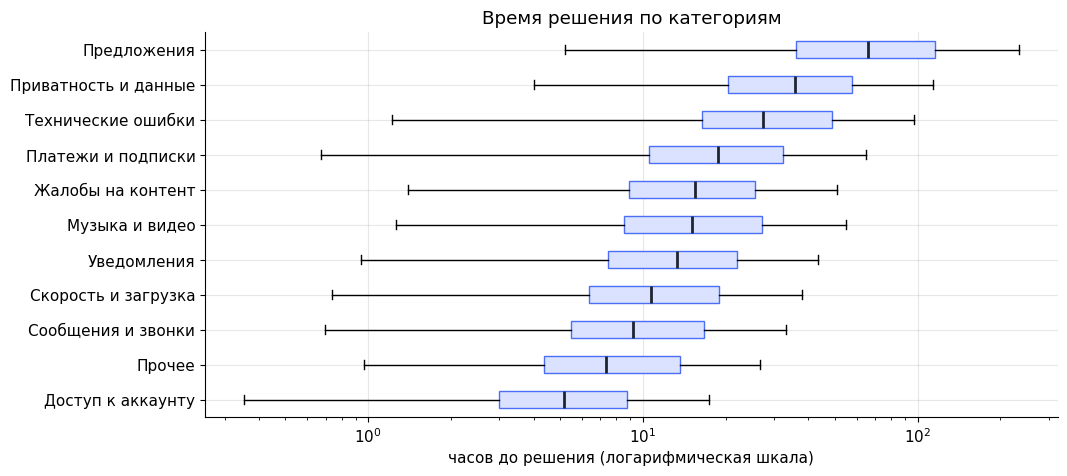

In [12]:
closed = df.dropna(subset=["resolution_h"])
order_res = closed.groupby("category_name")["resolution_h"].median().sort_values().index
fig, ax = plt.subplots(figsize=(11, 5))
ax.boxplot([closed.loc[closed["category_name"] == c, "resolution_h"] for c in order_res],
           vert=False, tick_labels=order_res, showfliers=False, patch_artist=True,
           boxprops=dict(facecolor="#dbe2ff", color="#4C6EF5"), medianprops=dict(color="#1f2433", lw=2))
ax.set_xscale("log"); ax.set_xlabel("часов до решения (логарифмическая шкала)")
ax.set_title("Время решения по категориям"); plt.show()

In [13]:
# Связь времени решения и оценки: делю на корзины и считаю средний CSAT
rated = closed.dropna(subset=["csat"]).copy()
rated["корзина"] = pd.cut(rated["resolution_h"], [0, 4, 12, 24, 48, 96, np.inf],
                          labels=["до 4 ч", "4–12 ч", "12–24 ч", "1–2 дня", "2–4 дня", "дольше 4 дней"])
t = rated.groupby("корзина", observed=True)["csat"].agg(["mean", "count"]).round(2)
rho = rated[["resolution_h", "csat"]].corr(method="spearman").iloc[0, 1]
print(f"Корреляция Спирмена между временем решения и оценкой: {rho:.2f}")
t.rename(columns={"mean": "средний CSAT", "count": "оценок"})

Корреляция Спирмена между временем решения и оценкой: -0.30


,средний CSAT,оценок
корзина,,
до 4 ч,4.38,615
4–12 ч,4.32,1888
12–24 ч,4.20,1495
1–2 дня,3.99,1048
2–4 дня,3.51,498
дольше 4 дней,2.70,184


Чем дольше человек ждёт, тем ниже оценка — связь устойчивая и отрицательная. Самые медленные
категории — «Предложения» и «Приватность и данные». С предложениями это нормально (их не решают,
а передают продукту), а вот запросы по персональным данным имеют регламентированные сроки ответа,
и медиана в полтора дня там — повод пересмотреть процесс.

## 7. Можно ли доверить разметку ключевым словам

В приложении каждое новое обращение получает категорию автоматически: словарь основ слов и фраз,
баллы за совпадения, побеждает максимум. Оператор может исправить категорию, и тогда в базе
остаются обе — автоматическая и итоговая. Это даёт честную оценку качества.

In [14]:
acc = an.categorizer_accuracy(df)
print(f"Совпадение автокатегории с итоговой: {acc['accuracy']}%")
pd.Series(acc["by_category"], name="точность, %").to_frame().T

Совпадение автокатегории с итоговой: 84.9%


,Музыка и видео,Сообщения и звонки,Прочее,Предложения,Доступ к аккаунту,Приватность и данные,Жалобы на контент,Технические ошибки,Платежи и подписки,Уведомления,Скорость и загрузка
"точность, %",61.0,73.0,86.2,87.4,87.8,88.3,88.3,88.9,89.0,89.2,89.4


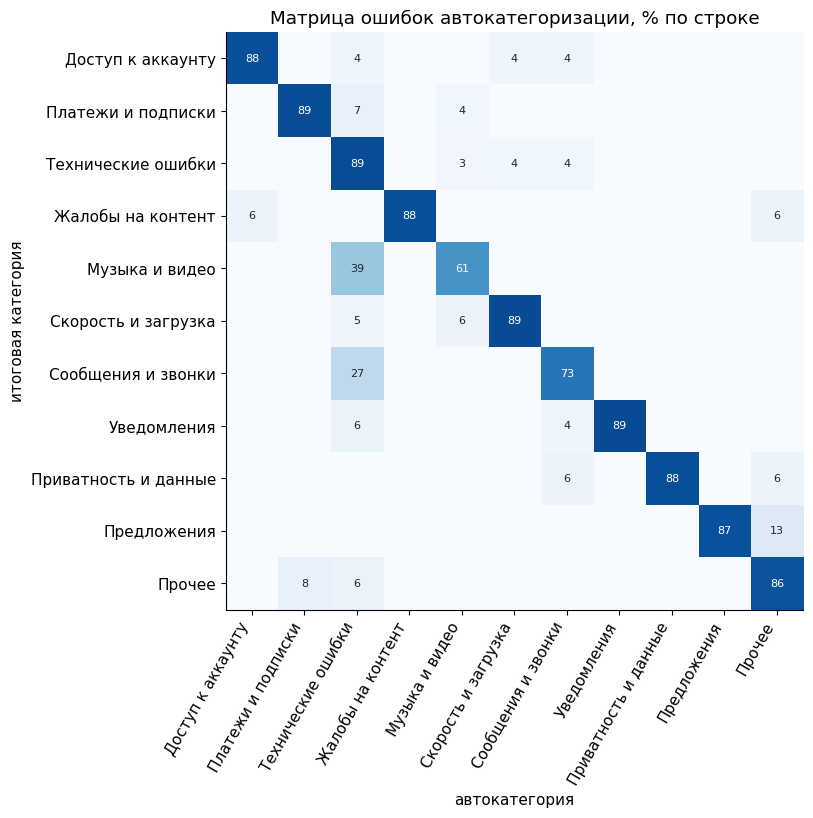

In [15]:
names = {k: v["name"] for k, v in DEFAULT_CATEGORIES.items()}
cm = pd.crosstab(df["category"].map(names), df["auto_category"].map(names), normalize="index") * 100
cm = cm.reindex(index=order, columns=order, fill_value=0)
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(cm.values, cmap="Blues", vmin=0, vmax=100)
ax.set_xticks(range(len(order)), order, rotation=60, ha="right"); ax.set_yticks(range(len(order)), order)
for i in range(len(order)):
    for j in range(len(order)):
        v = cm.values[i, j]
        if v >= 1:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8, color="white" if v > 60 else "#1f2433")
ax.set_xlabel("автокатегория"); ax.set_ylabel("итоговая категория"); ax.grid(False)
ax.set_title("Матрица ошибок автокатегоризации, % по строке"); plt.show()

In [16]:
# Где ошибается: самые частые пары «было → стало»
err = df[df["category"] != df["auto_category"]]
pairs = (err.groupby([err["auto_category"].map(names), err["category"].map(names)]).size()
         .sort_values(ascending=False).head(8).rename("случаев").reset_index())
pairs.columns = ["автоматически", "исправлено на", "случаев"]
display(pairs)
err[["subject", "text", "auto_category", "category"]].sample(6, random_state=1)

,автоматически,исправлено на,случаев
0,Технические ошибки,Музыка и видео,441
1,Технические ошибки,Сообщения и звонки,276
2,Технические ошибки,Платежи и подписки,154
3,Скорость и загрузка,Доступ к аккаунту,99
4,Сообщения и звонки,Доступ к аккаунту,98
5,Технические ошибки,Доступ к аккаунту,93
6,Музыка и видео,Платежи и подписки,85
7,Скорость и загрузка,Технические ошибки,73


,subject,text,auto_category,category
6483,Не загружаются фото,"Добрый день. Уже писал вам, ответа нет. Фотографии не загружаются в альбом, долго груз...",performance,bugs
10377,Трансляция зависает,"Добрый день. Прямой эфир зависает каждые пару минут. Помогите, пожалуйста.",bugs,media
6680,Не работает,"Здравствуйте! Приложение не работает нормально, всё открывается по минуте. Разберитесь...",bugs,performance
5049,Помогите,"Здравствуйте. Друзья пишут, что от моего имени приходят странные сообщения со ссылками...",messages,account_access
11080,Сообщения,Добрый вечер! Сообщения дублируются по два раза в диалоге. Устройство: Poco X5. Спасибо.,messages,bugs
5834,Трансляция зависает,Прямой эфир зависает каждые пару минут.,bugs,media


In [17]:
# Уверенность как сигнал: если уверенность низкая, обращение стоит отдать человеку
df["conf_bin"] = pd.cut(df["confidence"], [-0.01, 0.5, 0.7, 0.99, 1.0], labels=["≤50%", "50–70%", "70–99%", "100%"])
q = df.groupby("conf_bin", observed=True).apply(
    lambda g: pd.Series({"обращений": len(g), "точность, %": round((g["category"] == g["auto_category"]).mean() * 100, 1)}),
    include_groups=False)
q

,обращений,"точность, %"
conf_bin,,
≤50%,1266.0,46.0
50–70%,606.0,83.7
70–99%,3023.0,83.5
100%,8115.0,91.6


Правила справляются с большей частью потока без участия человека. Ошибки предсказуемы: люди
описывают симптом («не работает», «ошибка»), а не причину, и такие обращения уходят в «Технические
ошибки», хотя по сути это музыка, сообщения или оплата. Хуже всего размечаются «Музыка и видео»
и «Сообщения и звонки» — там больше всего общих слов с другими категориями.

Практический вывод: уверенность работает как фильтр. Обращения со 100% уверенностью можно не
проверять, а низкую уверенность подсвечивать оператору. Следующий шаг — обучить классификатор
(TF-IDF + логистическая регрессия) на уже исправленной разметке: её в базе накопилось достаточно.

## 8. Детектор всплесков

Задача — поднять тревогу, когда в какой-то категории обращений становится резко больше обычного.
Метод, который работает в приложении:

* норма — среднее число обращений в категории за предыдущие 28 дней;
* разброс — стандартное отклонение за те же дни, но не меньше корня из среднего (для счётных данных
  это нижняя граница шума по Пуассону — так спокойные категории не дают ложных тревог);
* тревога, если `z = (сегодня − норма) / разброс ≥ 4`, обращений не меньше 10 и их хотя бы в 1,5 раза больше нормы.

In [18]:
spikes = an.spike_history(df, baseline_days=28, z_threshold=4, min_count=10)
spikes

,date,category,count,baseline,z,ratio
0,2026-03-04,Скорость и загрузка,11,2.6,5.1,4.16
1,2026-03-12,Платежи и подписки,68,7.4,19.5,9.24
2,2026-06-04,Уведомления,50,2.4,30.8,20.90
3,2026-06-05,Уведомления,42,4.1,4.2,10.23
4,2026-06-08,Музыка и видео,13,3.8,4.7,3.43
5,2026-08-18,Скорость и загрузка,73,4.0,34.5,18.25
6,2026-09-28,Доступ к аккаунту,37,10.1,7.4,3.66
7,2026-09-29,Доступ к аккаунту,61,10.9,8.1,5.58


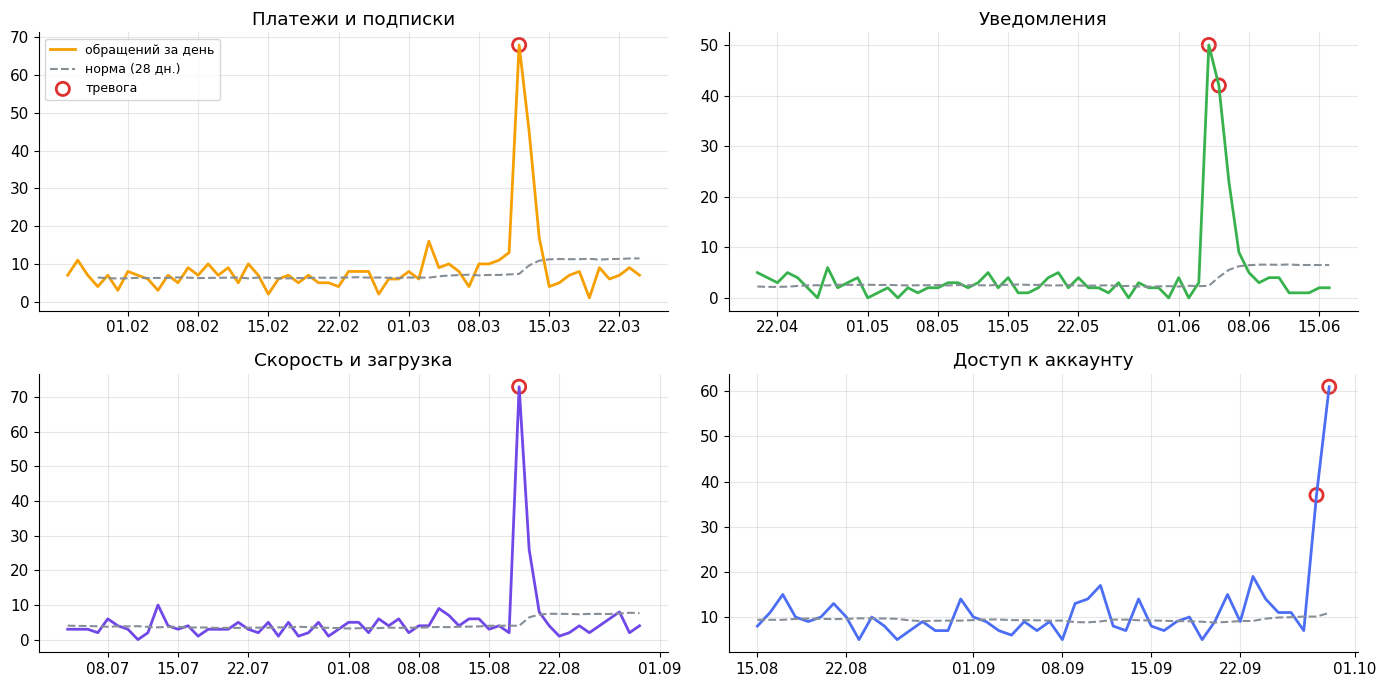

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharey=False)
counts = an.daily_counts(df)
for ax, (cat, day) in zip(axes.flat, [("Платежи и подписки", "2026-03-12"), ("Уведомления", "2026-06-04"),
                                      ("Скорость и загрузка", "2026-08-18"), ("Доступ к аккаунту", "2026-09-29")]):
    s = counts[cat].loc[pd.Timestamp(day) - pd.Timedelta(days=45): pd.Timestamp(day) + pd.Timedelta(days=12)]
    base = counts[cat].shift(1).rolling(28).mean().loc[s.index]
    ax.plot(s.index, s.values, color=COLORS[cat], lw=2, label="обращений за день")
    ax.plot(base.index, base.values, "--", color="#868e96", label="норма (28 дн.)")
    hit = spikes[spikes["category"] == cat]
    hit = hit[pd.to_datetime(hit["date"]).isin(s.index)]
    ax.scatter(pd.to_datetime(hit["date"]), hit["count"], s=90, facecolors="none", edgecolors="#e03131", lw=2, label="тревога")
    ax.set_title(cat); ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
axes[0, 0].legend(fontsize=9); plt.tight_layout(); plt.show()

In [20]:
# Что стояло за каждым инцидентом: самые частые теги в дни всплесков
for _, r in spikes.iterrows():
    day = df[(df["date"] == pd.Timestamp(r["date"])) & (df["category_name"] == r["category"])]
    tags = day["tags"].explode().value_counts().head(3)
    print(f"{r['date']:%d.%m} · {r['category']}: {r['count']} обращений (норма {r['baseline']:.0f}); "
          f"теги: {', '.join(f'{t} ({c})' for t, c in tags.items()) or '—'}")

04.03 · Скорость и загрузка: 11 обращений (норма 3); теги: android (3), ios (2)
12.03 · Платежи и подписки: 68 обращений (норма 7); теги: двойное списание (62), возврат средств (29), после обновления (28)
04.06 · Уведомления: 50 обращений (норма 2); теги: ios (46), после обновления (46), повторное (7)
05.06 · Уведомления: 42 обращений (норма 4); теги: ios (41), после обновления (41), повторное (2)
08.06 · Музыка и видео: 13 обращений (норма 4); теги: android (3), повторное (2), ios (2)
18.08 · Скорость и загрузка: 73 обращений (норма 4); теги: ios (12), android (9), повторное (6)
28.09 · Доступ к аккаунту: 37 обращений (норма 10); теги: sms-код (25), android (11), ios (7)
29.09 · Доступ к аккаунту: 61 обращений (норма 11); теги: sms-код (51), android (8), ios (7)


In [21]:
# Чувствительность: сколько дней с тревогой даёт каждый порог
sens = pd.DataFrame([{"порог z": z, "дней с тревогой": len(an.spike_history(df, z_threshold=z))}
                     for z in [2, 2.5, 3, 3.5, 4, 5, 6]])
sens.set_index("порог z").T

порог z,2.0,2.5,3.0,3.5,4.0,5.0,6.0
дней с тревогой,43,31,20,10,8,6,5


Детектор нашёл все четыре инцидента — в первый же день. При пороге 2–3 он начинает срабатывать
на случайные колебания (для счётных данных это ожидаемо: 11 категорий × 270 дней — это почти три тысячи
проверок, и при z = 3 несколько ложных тревог неизбежны). Порог 4 — компромисс: все инциденты ловятся, а лишних
срабатываний за девять месяцев два (4 марта и 8 июня), оба мелкие — 11 и 13 обращений. По тегам видно,
что за ними нет общего симптома, в отличие от настоящих инцидентов, где один тег собирает большинство обращений. Поэтому он стоит по умолчанию, а поменять его можно через переменную
окружения `SPIKE_Z_THRESHOLD`.

## 9. Сравнение периодов: сентябрь против августа

In [22]:
a = df[(df["date"] >= "2026-09-01") & (df["date"] <= "2026-09-29")]
b = df[(df["date"] >= "2026-08-01") & (df["date"] <= "2026-08-29")]
cmp = an.compare_periods(a, b)
print(f"Сентябрь: {len(a)}, август: {len(b)}, изменение {an._pct(len(a), len(b)):+.1f}%")
cmp.style.format({"delta_pct": "{:+.1f}%", "share_a": "{:.1f}", "share_b": "{:.1f}"}, na_rep="—") \
    .bar(subset=["delta"], align="zero", color=["#b2f2bb", "#ffc9c9"])

Сентябрь: 1597, август: 1614, изменение -1.1%


,category_name,period_a,period_b,delta,delta_pct,share_a,share_b
0,Доступ к аккаунту,367,264,103,+39.0%,23.0,16.4
1,Платежи и подписки,252,205,47,+22.9%,15.8,12.7
2,Технические ошибки,247,243,4,+1.6%,15.5,15.1
3,Жалобы на контент,144,143,1,+0.7%,9.0,8.9
4,Сообщения и звонки,128,134,-6,-4.5%,8.0,8.3
5,Музыка и видео,122,148,-26,-17.6%,7.6,9.2
6,Скорость и загрузка,102,219,-117,-53.4%,6.4,13.6
7,Уведомления,88,98,-10,-10.2%,5.5,6.1
8,Приватность и данные,65,65,0,+0.0%,4.1,4.0
9,Предложения,54,65,-11,-16.9%,3.4,4.0


Сравнение «в лоб» надо читать с оглядкой на инциденты: август раздут сбоем 18-го числа, поэтому
«Скорость и загрузка» в сентябре как будто резко упала. А рост «Доступа к аккаунту» — это
сентябрьская проблема с SMS-кодами. Без детектора всплесков такое сравнение легко принять за тренд.

## 10. Рейтинг конкретных проблем

In [23]:
last30 = df[df["date"] > df["date"].max() - pd.Timedelta(days=30)]
prev30 = df[(df["date"] <= df["date"].max() - pd.Timedelta(days=30)) & (df["date"] > df["date"].max() - pd.Timedelta(days=60))]
an.top_problems(last30, prev30, n=15)

,rank,problem,kind,count,prev,delta_pct,share
0,1,Доступ к аккаунту,категория,381,271,40.6,22.7
1,2,Платежи и подписки,категория,269,217,24.0,16.0
2,3,Технические ошибки,категория,261,251,4.0,15.6
3,4,Жалобы на контент,категория,148,146,1.4,8.8
4,5,Сообщения и звонки,категория,132,137,-3.6,7.9
5,6,#повторное,тег,128,127,0.8,7.6
6,7,Музыка и видео,категория,127,153,-17.0,7.6
7,8,Скорость и загрузка,категория,110,223,-50.7,6.6
8,9,#sms-код,тег,103,21,390.5,6.1
9,10,Уведомления,категория,93,103,-9.7,5.5


In [24]:
# Повторные обращения — индикатор того, что проблему не решили с первого раза
rep = df.assign(repeat=df["tags"].map(lambda t: "повторное" in t))
r = rep.groupby("category_name").agg(доля_повторных=("repeat", "mean"), CSAT=("csat", "mean"))
r["доля_повторных"] = (r["доля_повторных"] * 100).round(1)
r.sort_values("доля_повторных", ascending=False).round(2)

,доля_повторных,CSAT
category_name,,
Платежи и подписки,11.0,4.05
Приватность и данные,8.2,3.78
Доступ к аккаунту,7.9,4.34
Скорость и загрузка,7.8,4.23
Предложения,7.5,3.44
Жалобы на контент,7.4,4.12
Музыка и видео,6.8,4.13
Прочее,6.7,4.21
Технические ошибки,6.5,3.96


## 11. Выводы

**1. Поток растёт вместе с аудиторией.** С января по сентябрь — с ~39 до ~57 обращений в день, плюс 46%.
Если темп сохранится, к декабрю будет около 63 обращений в день — ещё плюс 10% к нагрузке. Нагрузку лучше распределять по фактическому профилю: понедельник на 51% тяжелее субботы,
половина обращений приходит в два окна — 10–14 и 19–23.

**2. Половина всех обращений — три темы:** доступ к аккаунту (18%), платежи и подписки (17%),
технические ошибки (15%). Структура стабильна, её меняют только инциденты. Значит, базу знаний и
шаблоны ответов имеет смысл в первую очередь вкладывать в эти три категории.

**3. Долгое ожидание прямо бьёт по оценке.** Решили за 4 часа — средний CSAT 4,4; ждали больше четырёх
дней — 2,7. Самые медленные и самые «недовольные» категории — «Предложения» (медиана 66 ч, CSAT 3,4)
и «Приватность и данные» (36 ч, 3,8). Для второй стоит завести отдельную очередь с контролем сроков:
у запросов по персональным данным есть регламент. По платежам самая высокая доля повторных обращений
(11%) — проблема часто не решается с первого ответа.

**4. Автокатегоризация по ключевым словам работает, но не везде.** 85% обращений размечаются верно
без участия человека, при 100% уверенности — 92%. Слабые места — «Музыка и видео» (61%) и
«Сообщения и звонки» (73%): их симптомы («не работает», «ошибка», «зависает») совпадают со словарём
технических ошибок. Решение в два шага: сейчас — показывать оператору обращения с уверенностью ниже 50%
(там точность 46%), дальше — обучить ML-классификатор на исправленной разметке, её накопилось почти две тысячи примеров.

**5. Инциденты видны в обращениях раньше, чем в любом отчёте.** Детектор на скользящей норме и z-оценке
нашёл все четыре инцидента в первый день: двойное списание после обновления (12.03), пропавшие push
на iOS (04.06, 94% обращений — с iOS), сбой производительности (18.08) и недоставку SMS-кодов (28–29.09).
Последний инцидент идёт прямо сейчас: 61 обращение за 29 сентября при норме 11. Это сигнал для
дежурной команды, а не для еженедельного отчёта.

**6. Сравнение периодов без учёта инцидентов обманывает.** Сентябрь к августу выглядит как «−1%
обращений и −51% жалоб на скорость», хотя на деле август раздут одним сбоем, а сентябрь — другим.
Поэтому в приложении сравнение периодов показывается рядом со списком всплесков.

**Что уже реализовано в приложении по итогам анализа:** автокатегоризация с объяснением сработавших слов,
автотеги и приоритет, детектор всплесков с уведомлением на дашборде, рейтинг проблем с динамикой,
сравнение периодов, тепловая карта нагрузки и экспорт отчёта в Excel/CSV.

**Ограничения.** Данные — одна выгрузка за 9 месяцев; сезонность внутри года по ней не оценить.
CSAT ставят 44% пользователей, и это не случайная выборка: оценку чаще оставляют те, у кого всё
решилось, так что реальная удовлетворённость, скорее всего, ниже.